In [17]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.optimize as opt

In [18]:
# Data parsing function. Expects just floats/ints, commas, and whitespaces and returns a np array.
def parse_data(fname):
    with open(fname, "r") as f:
        text_data = f.read()
    string_values = [val.strip() for val in text_data.split(",") if val.strip()]
    return np.array(string_values, dtype=float)

In [19]:
#1: Pulsed ODMR raw data and Lorentzian curve fit

# Will follow similar structure as Rabi Code below but with Lorentzian fit.

0.15581546478721572 0.010672746825996875 -888502219.6867965 0.8440085360413107


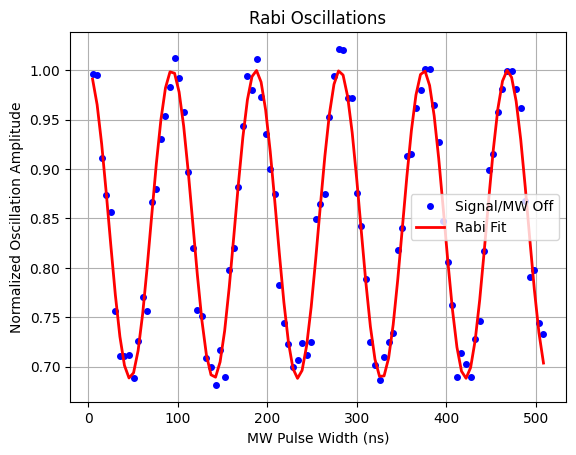

In [55]:
#2: Rabi Oscillations raw data and exponential decay fit

# Raw data parsing
durationftns = parse_data("RabiData/durationftus.txt")*1000 #convert times in us to ns by multiplying by 1000
signal1 = parse_data("RabiData/signal1.txt")
signal2 = parse_data("RabiData/signal2.txt")

# Exponentially decaying sine fit
def expsinefit(x, A, f, tau, C):
    return (A*np.cos(2*np.pi*f*x)*np.exp(-1*x/tau)) + C
# Fitting data to model using least squares
amp_uncertainties = np.sqrt(signal1/signal2) # std dev is error for poisson distribution
guesses = [0.15, 10e6/1e9, 50000.0, 0.84]
param, cov = opt.curve_fit(expsinefit, durationftns, signal1/signal2, guesses)
print(*param)
# Calculate rabi fit with optimal parameters
rabi_fit = expsinefit(durationftns, *param)

# Plot raw data and rabi fit overlayed
plt.plot(durationftns, signal1/signal2, 'bo', markersize=4, label="Signal/MW Off")
plt.plot(durationftns, rabi_fit, color="red", linewidth=2, label="Rabi Fit")
plt.legend()
plt.xlabel("MW Pulse Width (ns)")
plt.ylabel("Normalized Oscillation Amplitude")
plt.title("Rabi Oscillations")
plt.grid()
plt.show()

In [ ]:
#3: T2 measurement.  TBD

In [ ]:
#4: T1 measurement. TBD